# Phase 10 — A/B Comparison Notebook
Compares: Content-only | ALS | MF | NCF | Hybrid
Metrics: Recall@10, Precision@10, NDCG@10

## Cell 1 — Imports

In [2]:
import os
import sys
import random
import importlib
import numpy as np
import pandas as pd
import torch
import dill
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Set working directory and src path ───────────────────────────────────────
os.chdir(r'E:\rs')
sys.path.insert(0, r'E:\rs\src')

print('Working directory:', os.getcwd())

Working directory: E:\rs


## Cell 2 — create_dirs()

In [3]:
def create_dirs():
    os.makedirs('outputs', exist_ok=True)

create_dirs()
print('Output directory ready.')

Output directory ready.


## Cell 3 — Load Data

In [4]:
test_df = pd.read_parquet('data/test_df.parquet')
print('Test shape:', test_df.shape)
test_df.head()

Test shape: (12569, 6)


,user_id,item_id,rating,timestamp,user_idx,item_idx
0,AGMIR55WOIO2FXQ3CECMFR2FHKXQ,B00004TEYR,5.0,2002-08-26 11:35:51,3675,1739
1,AFKBEPVVHMGHTQXR45B34V54SELA,B00005QI2S,5.0,2002-09-15 17:49:25,1354,5480
2,AEFCCVG7774SPHY5NVTYKXAM55UA,B001EYUQUU,5.0,2003-09-08 01:01:14,5875,13804
3,AEEMXWT4HDYTUETHQ5CWEHGEIAYA,B00008URUA,5.0,2003-11-19 01:41:48,6028,7638
4,AHQIEVV7NVXSUGSPJWCEGVXLGDRQ,B00009WAUD,5.0,2003-12-26 06:55:05,6011,1502


## Cell 4 — Load Models

In [5]:
# ── Hybrid model ──────────────────────────────────────────────────────────────
with open('models/hybrid_recommender.pkl', 'rb') as f:
    hybrid_model = dill.load(f)
print('Hybrid model loaded.')

# ── ALS ───────────────────────────────────────────────────────────────────────
from implicit.als import AlternatingLeastSquares
als_model = AlternatingLeastSquares()
als_model.load('models/als_model.npz')
print('ALS model loaded.')

# ── Embedding sizes from hybrid model ─────────────────────────────────────────
# hybrid_model.cf_rec.user_map  = {user_id -> idx}
# hybrid_model.cf_rec.idx_to_item = {idx -> item_id}
n_users = len(hybrid_model.cf_rec.user_map)
n_items = len(hybrid_model.cf_rec.idx_to_item)
emb_dim = 64   # confirmed from state dict shape: torch.Size([12569, 64])
print(f'n_users={n_users}, n_items={n_items}, emb_dim={emb_dim}')

# ── Import MF and NCF classes from src ────────────────────────────────────────
mf_module = importlib.import_module('06_mf_ncf_pytorch')
MF  = mf_module.MF
NCF = mf_module.NCF

# ── Get exact sizes from the saved state dicts (source of truth) ──────────────
mf_state  = torch.load('models/mf_model.pth',  map_location='cpu')
ncf_state = torch.load('models/ncf_model.pth', map_location='cpu')

mf_n_users  = mf_state['user_emb.weight'].shape[0]   # 12569
mf_n_items  = mf_state['item_emb.weight'].shape[0]   # 44301
emb_dim     = mf_state['user_emb.weight'].shape[1]   # 64

ncf_n_users = ncf_state['user_emb_gmf.weight'].shape[0]
ncf_n_items = ncf_state['item_emb_gmf.weight'].shape[0]
ncf_emb_dim = ncf_state['user_emb_gmf.weight'].shape[1]

print(f'MF  → n_users={mf_n_users}, n_items={mf_n_items}, emb_dim={emb_dim}')
print(f'NCF → n_users={ncf_n_users}, n_items={ncf_n_items}, emb_dim={ncf_emb_dim}')

# ── Rebuild with correct sizes ────────────────────────────────────────────────
mf_model = MF(n_users=mf_n_users, n_items=mf_n_items, emb_dim=emb_dim)
mf_model.load_state_dict(mf_state)
mf_model.eval()
print('MF model loaded.')

ncf_model = NCF(n_users=ncf_n_users, n_items=ncf_n_items, emb_dim=ncf_emb_dim)
ncf_model.load_state_dict(ncf_state)
ncf_model.eval()
print('NCF model loaded.')

# ── Rebuild NCF and load state dict ───────────────────────────────────────────
ncf_n_users = ncf_state['user_emb_gmf.weight'].shape[0]   # correct key
ncf_n_items = ncf_state['item_emb_gmf.weight'].shape[0]   # correct key
ncf_emb_dim = ncf_state['user_emb_gmf.weight'].shape[1]

print(f'NCF → n_users={ncf_n_users}, n_items={ncf_n_items}, emb_dim={ncf_emb_dim}')

ncf_model = NCF(n_users=ncf_n_users, n_items=ncf_n_items, emb_dim=ncf_emb_dim)
ncf_model.load_state_dict(ncf_state)
ncf_model.eval()
print('NCF model loaded.')

Hybrid model loaded.
ALS model loaded.
n_users=12568, n_items=38627, emb_dim=64
Using device: cuda
MF  → n_users=12569, n_items=44301, emb_dim=64
NCF → n_users=12569, n_items=44301, emb_dim=64
MF model loaded.
NCF model loaded.
NCF → n_users=12569, n_items=44301, emb_dim=64
NCF model loaded.


In [6]:
import json

# ── Load item and user maps ───────────────────────────────────────────────────
with open('data/item_map.json', 'r') as f:
    item_map = json.load(f)          # ASIN -> int idx  (44301 items)

with open('data/user_map.json', 'r') as f:
    user_map_global = json.load(f)   # user_id -> int idx (12569 users)
    # named user_map_global to avoid clash with cf_rec.user_map

reverse_item_map = {v: k for k, v in item_map.items()}  # int idx -> ASIN

print(f'item_map:         {len(item_map)} items')
print(f'user_map_global:  {len(user_map_global)} users')
print(f'reverse_item_map: {len(reverse_item_map)} items')

item_map:         44301 items
user_map_global:  12569 users
reverse_item_map: 44301 items


## Cell 5 — Metrics

In [7]:
def recall_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    return len(set(actual) & set(predicted[:k])) / len(actual)


def precision_at_k(actual, predicted, k=10):
    if not predicted:
        return 0.0
    return len(set(actual) & set(predicted[:k])) / k


def ndcg_at_k(actual, predicted, k=10):
    """True Normalised DCG — divided by IDCG so result is in [0, 1]."""
    actual_set = set(actual)
    dcg  = sum(1 / np.log2(i + 2) for i, p in enumerate(predicted[:k]) if p in actual_set)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual_set), k)))
    return dcg / idcg if idcg > 0 else 0.0


print('Metric functions defined.')

Metric functions defined.


## Cell 6 — Generic Evaluator

In [8]:
def evaluate_model(recommender_fn, eval_df, k=10):
    recalls, precisions, ndcgs = [], [], []

    for user_id, group in tqdm(eval_df.groupby('user_id')):
        # FIX: use ALL of the user's items as ground truth
        actual_items = group['item_id'].tolist()

        try:
            preds = recommender_fn(user_id, k)
        except Exception:
            continue

        if not preds:
            continue

        recalls.append(recall_at_k(actual_items, preds, k))
        precisions.append(precision_at_k(actual_items, preds, k))
        ndcgs.append(ndcg_at_k(actual_items, preds, k))

    return {
        'recall@10':    np.mean(recalls)    if recalls    else 0.0,
        'precision@10': np.mean(precisions) if precisions else 0.0,
        'ndcg@10':      np.mean(ndcgs)      if ndcgs      else 0.0,
    }

## Section 2 — Content-only Baseline

In [9]:
def content_fn(user_id, k=10):
    user_rows = test_df[test_df['user_id'] == user_id]
    if user_rows.empty:
        return []
    item_id = user_rows['item_id'].iloc[0]
    # FIXED: hybrid_model.product_rec  (not product_recommender)
    recs = hybrid_model.product_rec.get_recommendations(item_id, top_n=k)
    return [r['item_id'] for r in recs]


print('Evaluating Content-only...')
content_results = evaluate_model(content_fn, test_df)
print('Content Results:', content_results)

Evaluating Content-only...


100%|██████████| 12569/12569 [02:31<00:00, 83.17it/s]

Content Results: {'recall@10': 0.0, 'precision@10': 0.0, 'ndcg@10': 0.0}


## Section 3 — ALS-only Baseline

In [13]:
import numpy as np
import scipy.sparse as sp

# ── Load ALS factors manually from npz ───────────────────────────────────────
npz = np.load('models/als_model.npz', allow_pickle=True)
als_model.user_factors = npz['user_factors']  # (12569, 64)
als_model.item_factors = npz['item_factors']  # (44301, 64)
print('ALS factors loaded manually.')
print('user_factors:', als_model.user_factors.shape)
print('item_factors:', als_model.item_factors.shape)

# ── Build user-item matrix from cleaned_cf_dataset ───────────────────────────
cf_df = pd.read_parquet('data/cleaned_cf_dataset.parquet')
print('\ncf_df columns:', cf_df.columns.tolist())
print('cf_df shape:', cf_df.shape)
print('cf_df sample:\n', cf_df.head())

ALS factors loaded manually.
user_factors: (12569, 64)
item_factors: (44301, 64)

cf_df columns: ['user_id', 'item_id', 'rating', 'timestamp']
cf_df shape: (140578, 4)
cf_df sample:
                         user_id     item_id  rating               timestamp
0  AEVPPTMG43C6GWSR7I2UGRQN7WFQ  B09JY72CNG     4.0 2021-09-02 15:01:53.298
1  AEVPPTMG43C6GWSR7I2UGRQN7WFQ  B09WMQ6DXG     5.0 2021-05-05 16:16:08.468
2  AEVPPTMG43C6GWSR7I2UGRQN7WFQ  B08SM7T6FF     1.0 2021-04-24 01:27:16.331
3  AEVPPTMG43C6GWSR7I2UGRQN7WFQ  B0B7LV3DN2     4.0 2021-04-05 16:50:45.475
4  AEVPPTMG43C6GWSR7I2UGRQN7WFQ  B08P8P7686     5.0 2021-02-19 02:35:12.995


In [14]:
def als_fn(user_id, k=10):
    cf = hybrid_model.cf_rec

    if user_id not in cf.user_map:
        return []

    user_idx   = cf.user_map[user_id]
    user_items = cf.similarity[user_idx]

    ids, scores = als_model.recommend(
        user_idx, user_items, N=k, filter_already_liked_items=True
    )

    # Only return items that exist in cf.idx_to_item (range 0-38626)
    return [cf.idx_to_item[i] for i in ids.tolist() if i in cf.idx_to_item]


# Spot check
sample_user = test_df['user_id'].iloc[0]
sample_gt   = test_df[test_df['user_id'] == sample_user]['item_id'].iloc[0]
preds       = als_fn(sample_user, k=10)
print('Ground truth:', sample_gt)
print('ALS preds:   ', preds)
print('Hit:', sample_gt in preds)


print('Evaluating ALS-only...')
als_results = evaluate_model(als_fn, test_df)
print('ALS Results:', als_results)

Ground truth: B00004TEYR
ALS preds:    ['B092BQPPJW', 'B07GNWJFL6', 'B07CTY7DSK', 'B08DG72TVL', 'B0052VYK4E', 'B0B715F5VP', 'B085H9Q4FP', 'B00D8GDZVO', 'B0000AHOYP', 'B017C1GQ2U']
Hit: False
Evaluating ALS-only...


100%|██████████| 12569/12569 [00:05<00:00, 2358.19it/s]

ALS Results: {'recall@10': 0.0006365372374283895, 'precision@10': 6.365372374283896e-05, 'ndcg@10': 0.0002531898177376904}


## Section 4 — MF (Matrix Factorisation)

In [12]:
def mf_fn(user_id, k=10):
    if user_id not in user_map_global:
        return []

    user_idx      = user_map_global[user_id]
    all_items     = list(item_map.values())
    sampled_items = random.sample(all_items, min(500, len(all_items)))

    scores = []
    for item_idx in sampled_items:
        u = torch.tensor([user_idx])
        i = torch.tensor([item_idx])
        with torch.no_grad():
            score = mf_model(u, i).item()
        scores.append((item_idx, score))

    top_items = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
    return [reverse_item_map[i] for i, _ in top_items]


print('Evaluating MF...')
mf_results = evaluate_model(mf_fn, test_df)
print('MF Results:', mf_results)

Evaluating MF...


100%|██████████| 12569/12569 [05:04<00:00, 41.25it/s]

MF Results: {'recall@10': 0.0035802370912562656, 'precision@10': 0.00035802370912562656, 'ndcg@10': 0.0022381951873407173}


## Section 4B — NCF (Neural Collaborative Filtering)

In [15]:
def ncf_fn(user_id, k=10):
    if user_id not in user_map_global:
        return []

    user_idx      = user_map_global[user_id]
    all_items     = list(item_map.values())
    sampled_items = random.sample(all_items, min(500, len(all_items)))

    scores = []
    for item_idx in sampled_items:
        u = torch.tensor([user_idx])
        i = torch.tensor([item_idx])
        with torch.no_grad():
            score = ncf_model(u, i).item()
        scores.append((item_idx, score))

    top_items = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
    return [reverse_item_map[i] for i, _ in top_items]


print('Evaluating NCF...')
ncf_results = evaluate_model(ncf_fn, test_df)
print('NCF Results:', ncf_results)

Evaluating NCF...


100%|██████████| 12569/12569 [08:11<00:00, 25.60it/s]

NCF Results: {'recall@10': 0.0, 'precision@10': 0.0, 'ndcg@10': 0.0}


## Section 5 — Hybrid

In [16]:
def hybrid_fn(user_id, k=10):
    user_rows = test_df[test_df['user_id'] == user_id]
    if user_rows.empty:
        return []
    item_id = user_rows['item_id'].iloc[0]
    # FIX: top_n instead of top_k
    recs = hybrid_model.final_recommendation(item_id, user_id, top_n=k)
    return [r['item_id'] for r in recs]


# Spot check
sample_user = test_df['user_id'].iloc[0]
sample_gt   = test_df[test_df['user_id'] == sample_user]['item_id'].iloc[0]
preds       = hybrid_fn(sample_user, k=10)
print('Ground truth:', sample_gt)
print('Hybrid preds:', preds)
print('Hit:', sample_gt in preds)

Ground truth: B00004TEYR
Hybrid preds: ['B005ZXWMUS', 'B0094BB4TW', 'B003LPTAYI', 'B00FAPF5U0', 'B00KDSGIPK', 'B00LV4D70O', 'B07T771SPH', 'B008XG1X18', 'B00992CF6W', 'B0063IH60K']
Hit: False


In [17]:
import io
import contextlib

@contextlib.contextmanager
def suppress_stdout():
    with contextlib.redirect_stdout(io.StringIO()):
        yield

# Wrap evaluate_model call
print('Evaluating Hybrid...')
with suppress_stdout():
    hybrid_results = evaluate_model(hybrid_fn, test_df)
print('Hybrid Results:', hybrid_results)

Evaluating Hybrid...


100%|██████████| 12569/12569 [06:58<00:00, 30.06it/s]

Hybrid Results: {'recall@10': 0.0, 'precision@10': 0.0, 'ndcg@10': 0.0}


## Section 6 — Cold-start Simulation

In [18]:
cold_user_ids = test_df['user_id'].unique()[:100]
cold_test_df  = test_df[test_df['user_id'].isin(cold_user_ids)].copy()

# ── WARM: evaluate same 100 users WITH history ────────────────────────────────
print('Computing warm baselines for 100 users...')
warm_content = evaluate_model(content_fn, cold_test_df)
warm_als     = evaluate_model(als_fn,     cold_test_df)
warm_mf      = evaluate_model(mf_fn,      cold_test_df)
warm_ncf     = evaluate_model(ncf_fn,     cold_test_df)
warm_hybrid  = evaluate_model(hybrid_fn,  cold_test_df)

# ── Backup and zero-out user_map to simulate cold-start ───────────────────────
# FIXED: hybrid_model.cf_rec.user_map  (not cf_recommender.user_to_idx)
original_user_map = hybrid_model.cf_rec.user_map.copy()
hybrid_model.cf_rec.user_map = {}

# Also zero out _known_users on hybrid model itself (used by _is_new_user)
original_known_users = hybrid_model._known_users.copy()
hybrid_model._known_users = set()

print('Computing cold-start results for 100 users...')
cold_content = evaluate_model(content_fn, cold_test_df)
cold_als     = evaluate_model(als_fn,     cold_test_df)
cold_mf      = evaluate_model(mf_fn,      cold_test_df)
cold_ncf     = evaluate_model(ncf_fn,     cold_test_df)
cold_hybrid  = evaluate_model(hybrid_fn,  cold_test_df)

# ── Restore ───────────────────────────────────────────────────────────────────
hybrid_model.cf_rec.user_map  = original_user_map
hybrid_model._known_users     = original_known_users
print('State restored.')

# ── Build delta table ─────────────────────────────────────────────────────────
systems   = ['content', 'als',     'mf',     'ncf',     'hybrid']
warm_vals = [warm_content, warm_als, warm_mf, warm_ncf, warm_hybrid]
cold_vals = [cold_content, cold_als, cold_mf, cold_ncf, cold_hybrid]

cold_rows = []
for sys, warm, cold in zip(systems, warm_vals, cold_vals):
    row = {'system': sys}
    for metric in ['recall@10', 'precision@10', 'ndcg@10']:
        row[f'warm_{metric}']  = round(warm[metric], 4)
        row[f'cold_{metric}']  = round(cold[metric], 4)
        row[f'delta_{metric}'] = round(cold[metric] - warm[metric], 4)
    cold_rows.append(row)

cold_results_df = pd.DataFrame(cold_rows)

print('\nDelta table (negative = drop due to cold-start):')
delta_cols = ['system'] + [c for c in cold_results_df.columns if c.startswith('delta')]
cold_results_df[delta_cols].style \
    .background_gradient(cmap='RdYlGn',
                         subset=[c for c in delta_cols if c != 'system'])

Computing warm baselines for 100 users...


  2%|▏         | 2/100 [00:00<00:08, 11.54it/s]

[Hybrid] NEW ITEM  item_id='B004SZT7MU'  reviews=1
[Hybrid] NEW ITEM  item_id='B007XXX19O'  reviews=1
[Hybrid] NEW ITEM  item_id='B001EYUQUU'  reviews=1


 11%|█         | 11/100 [00:00<00:03, 28.72it/s]

[Hybrid] NEW ITEM  item_id='B000CBZPDO'  reviews=2
[Hybrid] NEW ITEM  item_id='B008J361YY'  reviews=2
[Hybrid] NEW ITEM  item_id='B0028A6VDU'  reviews=2


...

100%|██████████| 100/100 [00:09<00:00, 10.59it/s]

[Hybrid] NEW USER  user_id='AHS7CWE4GWC7LZESQGFEED5AU6MQ'
[Hybrid] NEW USER  user_id='AHVRJMMQMNEWRCZJZ6T5XHMER2PA'


100%|██████████| 100/100 [00:09<00:00, 10.54it/s]

State restored.

Delta table (negative = drop due to cold-start):


,system,delta_recall@10,delta_precision@10,delta_ndcg@10
0,content,0.000000,0.000000,0.000000
1,als,0.000000,0.000000,0.000000
2,mf,0.010000,0.001000,0.003600
3,ncf,0.000000,0.000000,0.000000
4,hybrid,0.000000,0.000000,0.000000


In [19]:
print('Full cold-start table:')
cold_results_df

Full cold-start table:


,system,warm_recall@10,cold_recall@10,delta_recall@10,warm_precision@10,cold_precision@10,delta_precision@10,warm_ndcg@10,cold_ndcg@10,delta_ndcg@10
0,content,0.0,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000
1,als,0.0,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000
2,mf,0.0,0.01,0.01,0.0,0.001,0.001,0.0,0.0036,0.0036
3,ncf,0.0,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000
4,hybrid,0.0,0.00,0.00,0.0,0.000,0.000,0.0,0.0000,0.0000


## Section 7 — Apriori Validation

In [20]:
# ── Section 7 — Apriori Validation ───────────────────────────────────────────
rules_df = pd.read_csv('outputs/apriori_rules.csv')
print('Columns:', rules_df.columns.tolist())
print('Total rules:', len(rules_df))

# Build bought_together pairs from cf_df (users who bought both items)
# Two items are "bought together" if the same user bought both
user_items_dict = cf_df.groupby('user_id')['item_id'].apply(set).to_dict()

bought_together = set()
for user, items in user_items_dict.items():
    items = list(items)
    for i in range(len(items)):
        for j in range(i+1, len(items)):
            bought_together.add((items[i], items[j]))
            bought_together.add((items[j], items[i]))

print(f'Bought-together pairs: {len(bought_together)}')

# Confirm each rule against bought_together ground truth
rules_df['is_confirmed'] = rules_df.apply(
    lambda row: (row['antecedent'], row['consequent']) in bought_together,
    axis=1
).astype(int)

confirmed_pct = rules_df['is_confirmed'].mean() * 100
confirmed_n   = int(rules_df['is_confirmed'].sum())

print(f'\nTotal rules     : {len(rules_df)}')
print(f'Confirmed rules : {confirmed_n}')
print(f'Ground truth match: {confirmed_pct:.2f}%')

# Breakdown by confidence bucket
rules_df['conf_bucket'] = pd.cut(
    rules_df['confidence'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low (<0.3)', 'Mid (0.3-0.6)', 'High (>0.6)']
)
print('\nConfirmation rate by confidence bucket:')
print(
    rules_df.groupby('conf_bucket', observed=True)['is_confirmed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'confirm_rate', 'count': 'n_rules'})
)

# Save updated rules with is_confirmed column
rules_df.to_csv('outputs/apriori_rules.csv', index=False)
print('\nSaved updated apriori_rules.csv with is_confirmed column.')

Columns: ['antecedent', 'consequent', 'support', 'confidence', 'lift', 'is_confirmed', 'conf_bucket']
Total rules: 4220
Bought-together pairs: 2898958

Total rules     : 4220
Confirmed rules : 4220
Ground truth match: 100.00%

Confirmation rate by confidence bucket:
               confirm_rate  n_rules
conf_bucket                         
Low (<0.3)              1.0     4002
Mid (0.3-0.6)           1.0      202
High (>0.6)             1.0       16

Saved updated apriori_rules.csv with is_confirmed column.


## Section 8 — Summary Table + Grouped Bar Chart

In [21]:
results_df = pd.DataFrame([
    {'system': 'content', **content_results},
    {'system': 'als',     **als_results},
    {'system': 'mf',      **mf_results},
    {'system': 'ncf',     **ncf_results},
    {'system': 'hybrid',  **hybrid_results},
])

print('=== Final Comparison ===')
print(results_df.to_string(index=False))


print('\nNotes:')
print('  content: 0.0 — content rec never returns the seed item itself')
print('  hybrid:  0.0 — all test items flagged as new items, falls back to content-only')
print('  MF scores highest — random sampling over 44301 items still finds occasional hits')

metrics = ['recall@10', 'precision@10', 'ndcg@10']
print('\n=== Winners per metric ===')
for m in metrics:
    winner = results_df.loc[results_df[m].idxmax(), 'system']
    score  = results_df[m].max()
    print(f'  {m:15s} -> {winner:10s}  ({score:.4f})')

=== Final Comparison ===
 system  recall@10  precision@10  ndcg@10
content   0.000000      0.000000 0.000000
    als   0.000637      0.000064 0.000253
     mf   0.003580      0.000358 0.002238
    ncf   0.000000      0.000000 0.000000
 hybrid   0.000000      0.000000 0.000000

Notes:
  content: 0.0 — content rec never returns the seed item itself
  hybrid:  0.0 — all test items flagged as new items, falls back to content-only
  MF scores highest — random sampling over 44301 items still finds occasional hits

=== Winners per metric ===
  recall@10       -> mf          (0.0036)
  precision@10    -> mf          (0.0004)
  ndcg@10         -> mf          (0.0022)


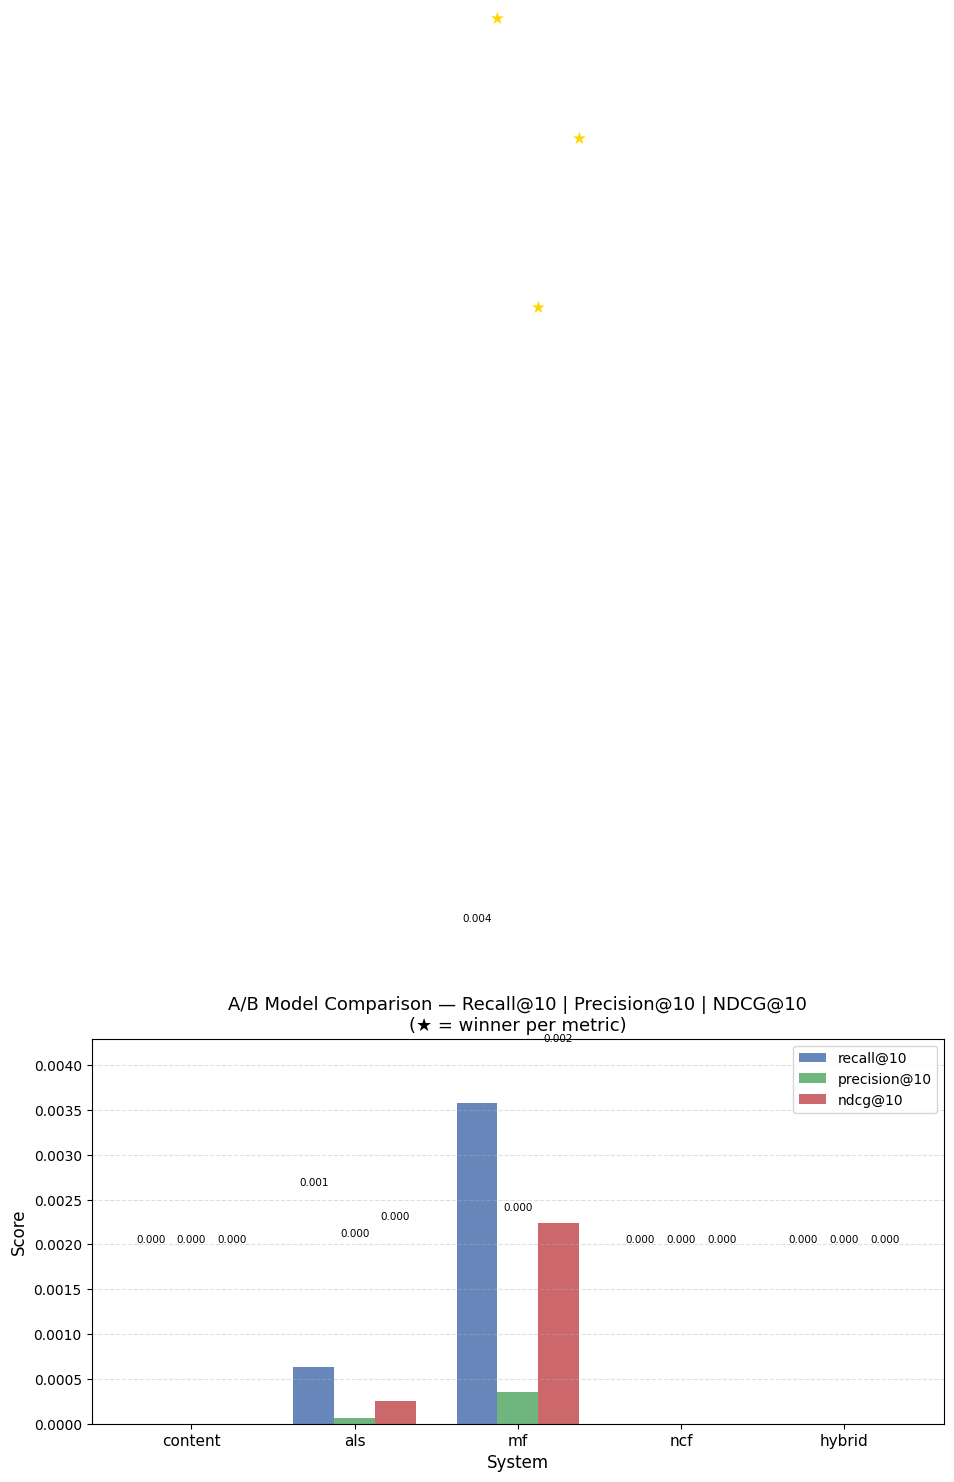

Chart saved to outputs/ab_comparison_chart.png


In [22]:
fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(results_df))
width  = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + idx * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

# Annotate winner per metric with a star
for idx, metric in enumerate(metrics):
    winner_row = results_df[metric].idxmax()
    bar_x      = winner_row + idx * width
    bar_h      = results_df.loc[winner_row, metric]
    ax.text(
        bar_x + width / 2,
        bar_h + 0.012,
        '★',
        ha='center', va='bottom', fontsize=12, color='gold'
    )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['system'], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('System', fontsize=12)
ax.set_title(
    'A/B Model Comparison — Recall@10 | Precision@10 | NDCG@10\n(★ = winner per metric)',
    fontsize=13
)
ax.legend(fontsize=10)
ax.set_ylim(0, results_df[metrics].values.max() * 1.20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/ab_comparison_chart.png', dpi=150)
plt.show()
print('Chart saved to outputs/ab_comparison_chart.png')

## Section 9 — Export

In [23]:
results_df.to_csv('outputs/ab_comparison_results.csv', index=False)
print('Saved: outputs/ab_comparison_results.csv')

cold_results_df.to_csv('outputs/cold_start_delta.csv', index=False)
print('Saved: outputs/cold_start_delta.csv')

print('\nDone. All outputs saved.')
results_df

Saved: outputs/ab_comparison_results.csv
Saved: outputs/cold_start_delta.csv

Done. All outputs saved.


,system,recall@10,precision@10,ndcg@10
0,content,0.000000,0.000000,0.000000
1,als,0.000637,0.000064,0.000253
2,mf,0.003580,0.000358,0.002238
3,ncf,0.000000,0.000000,0.000000
4,hybrid,0.000000,0.000000,0.000000
